In [3]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("/tf/ProjectGabriel/pilca")

import numpy as np
import pandas as pd
from lightcurve_fitting import models, lightcurve
from lightcurve_fitting import filters as flc
import matplotlib.pyplot as plt
import matplotlib as mpl
import importlib
from utils.utils import load_lc
from utils.utils import light_curve_plot
import torch
import utils.torchphysics as tp
import utils.utils as ut
import utils.analysis as an
# import lc
import os
torch.set_default_dtype(torch.float64)



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
all_filters = ["y", "z",  "i", "r", "g", "u"][::-1]#[-2:]  # from red to UV
mjd_array = np.linspace(3, 15, 100)

filter_combinations = [all_filters[:i+1] for i in range(len(all_filters))]

max_days = 12
time_spans = np.arange(1, max_days + 1)  # [1, 2, ..., 10]

model_parameters = [.35, 2., .2, 4.0, 2.5]

# --- setup light curve builder ---
builder = ut.LCBuilder(
    model_name="sc4",
    model_parameters=model_parameters,
    model_units=[1,1,1,1,1],
    seed=42)

lc = builder.build_sim_lc(
    mjd_array=mjd_array,
    filters_list=all_filters,  # full set
    redshift=0.00526,
    dlum_factor=1e-1/2,
    dm=31.1,
    dL=19.,
    dLerr=2.9
)

ten13cmtoRsol = 1e13*1.4374e-11
ten8p5cmstoten3kms = 10**.5

In [5]:
580/ten13cmtoRsol

4.035063308751913

In [6]:
model = models.ModifiedShockCooling4(lc)
model.t_max(model_parameters)

16.382471744387402

In [7]:
def get_filter_mask(lc, filters):
    filter_objects = [flc.filtdict[f] for f in filters]
    fmask = np.in1d(lc["filter"].value, filter_objects)
    return fmask

lc_subset = lc.where(MJD_max=lc["MJD"].min() + max_days)
lc_subset = lc_subset[get_filter_mask(lc_subset, filter_combinations[-1])]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

torchenizer = tp.Torchenizer(lc_subset, ycol="loglum", device=device)

X_DATA, filters_mask, ufilters = torchenizer.get_xdata(max_phase=max_days, t0_offset=3)

Using device: cpu


In [12]:
nn_model_name = "VariationalRNN_architecture.pth"
model_save_dir = os.path.join(ut.storage_parent_path, "models", nn_model_name)

# nn_model = tp.MultiFilterHybridBNN(x_data=X_DATA,
#                             filters_mask=filters_mask,
#                             param_dim=5,
#                             hidden_dim=16,
#                             n_filter_layers=2,
#                             n_combined_layers=2,
#                             dropout_rate=0.).to(device)

nn_model = tp.CorrelationVariationalRNN(
    x_data=X_DATA,
    filters_mask=filters_mask,
    param_dim=5,
    rnn_hidden_dim=16,
    rnn_layers=3,
    dense_hidden_dim=16,
    dense_layers=3,
    dropout_rate=0.0,
).to(device)

# nn_model = tp.PriorConstrainedReLUCorrelationVariationalRNN(
#     x_data=X_DATA,
#     filters_mask=filters_mask,
#     param_dim=5,
#     rnn_hidden_dim=16,
#     rnn_layers=3,
#     dense_hidden_dim=16,
#     dense_layers=3,
#     dropout_rate=0.0,
#     p_min=[0.01, 0.1, 0.01, 0.1, 1.],
#     p_max=[1, 10., 1, 10., 4.]
# ).to(device)
# [.35, 2., .2, 4.0, 2.5]
criterion = tp.VariationalSC4Loss(ufilters=ufilters,
                               z=lc.meta["redshift"],
                               mode="mean_model",
                               min_t0=torch.min(X_DATA[:,0])-1e-5,
                               fixed_frhom=builder.model_parameters[2],
                               p_min=None,#nn_model.p_min,
                               p_max=None)#nn_model.p_max)
lr=1e-2
optimizer = torch.optim.Adam(nn_model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer,
                                            step_size=50, gamma=0.8)

trainer = tp.VariationalTrainer(model=nn_model,
                    criterion=criterion,
                    epochs=2000,
                    n_samples_loss=100,
                    optimizer=optimizer,
                    scheduler=scheduler,
                    verbose_step=1,
                    save_dir=model_save_dir,
                    es_kwargs={"use_es":True,
                               "patience":50,
                               "save_best_loss":True},
                    change_loss=False)


In [ ]:
history = trainer.train()

sigma: 2.5063183606206407
negative penality: 0.03527576952795937
--- Step 0 ---
Shock velocity (v_s):     0.7439
Envelope mass (M_env):    0.8011
Density factor (f_rho_M): 0.5973
Radius (R):               0.8940
Explosion time (t_exp):   0.8690
Loss:                     0.101747
----------------------------------------
sigma: 2.5040793714011254
negative penality: 0.045326326483715214
--- Step 1 ---
Shock velocity (v_s):     0.7365
Envelope mass (M_env):    0.8084
Density factor (f_rho_M): 0.5926
Radius (R):               0.9259
Explosion time (t_exp):   0.8426
Loss:                     0.109703
----------------------------------------
sigma: 3.1613427993043155
negative penality: 0.023395673734048657
--- Step 2 ---
Shock velocity (v_s):     0.8378
Envelope mass (M_env):    0.7818
Density factor (f_rho_M): 0.6220
Radius (R):               0.9443
Explosion time (t_exp):   0.9660
Loss:                     0.100290
----------------------------------------
sigma: 3.537505301253453
negative p

In [ ]:
aa

NameError: name 'aa' is not defined

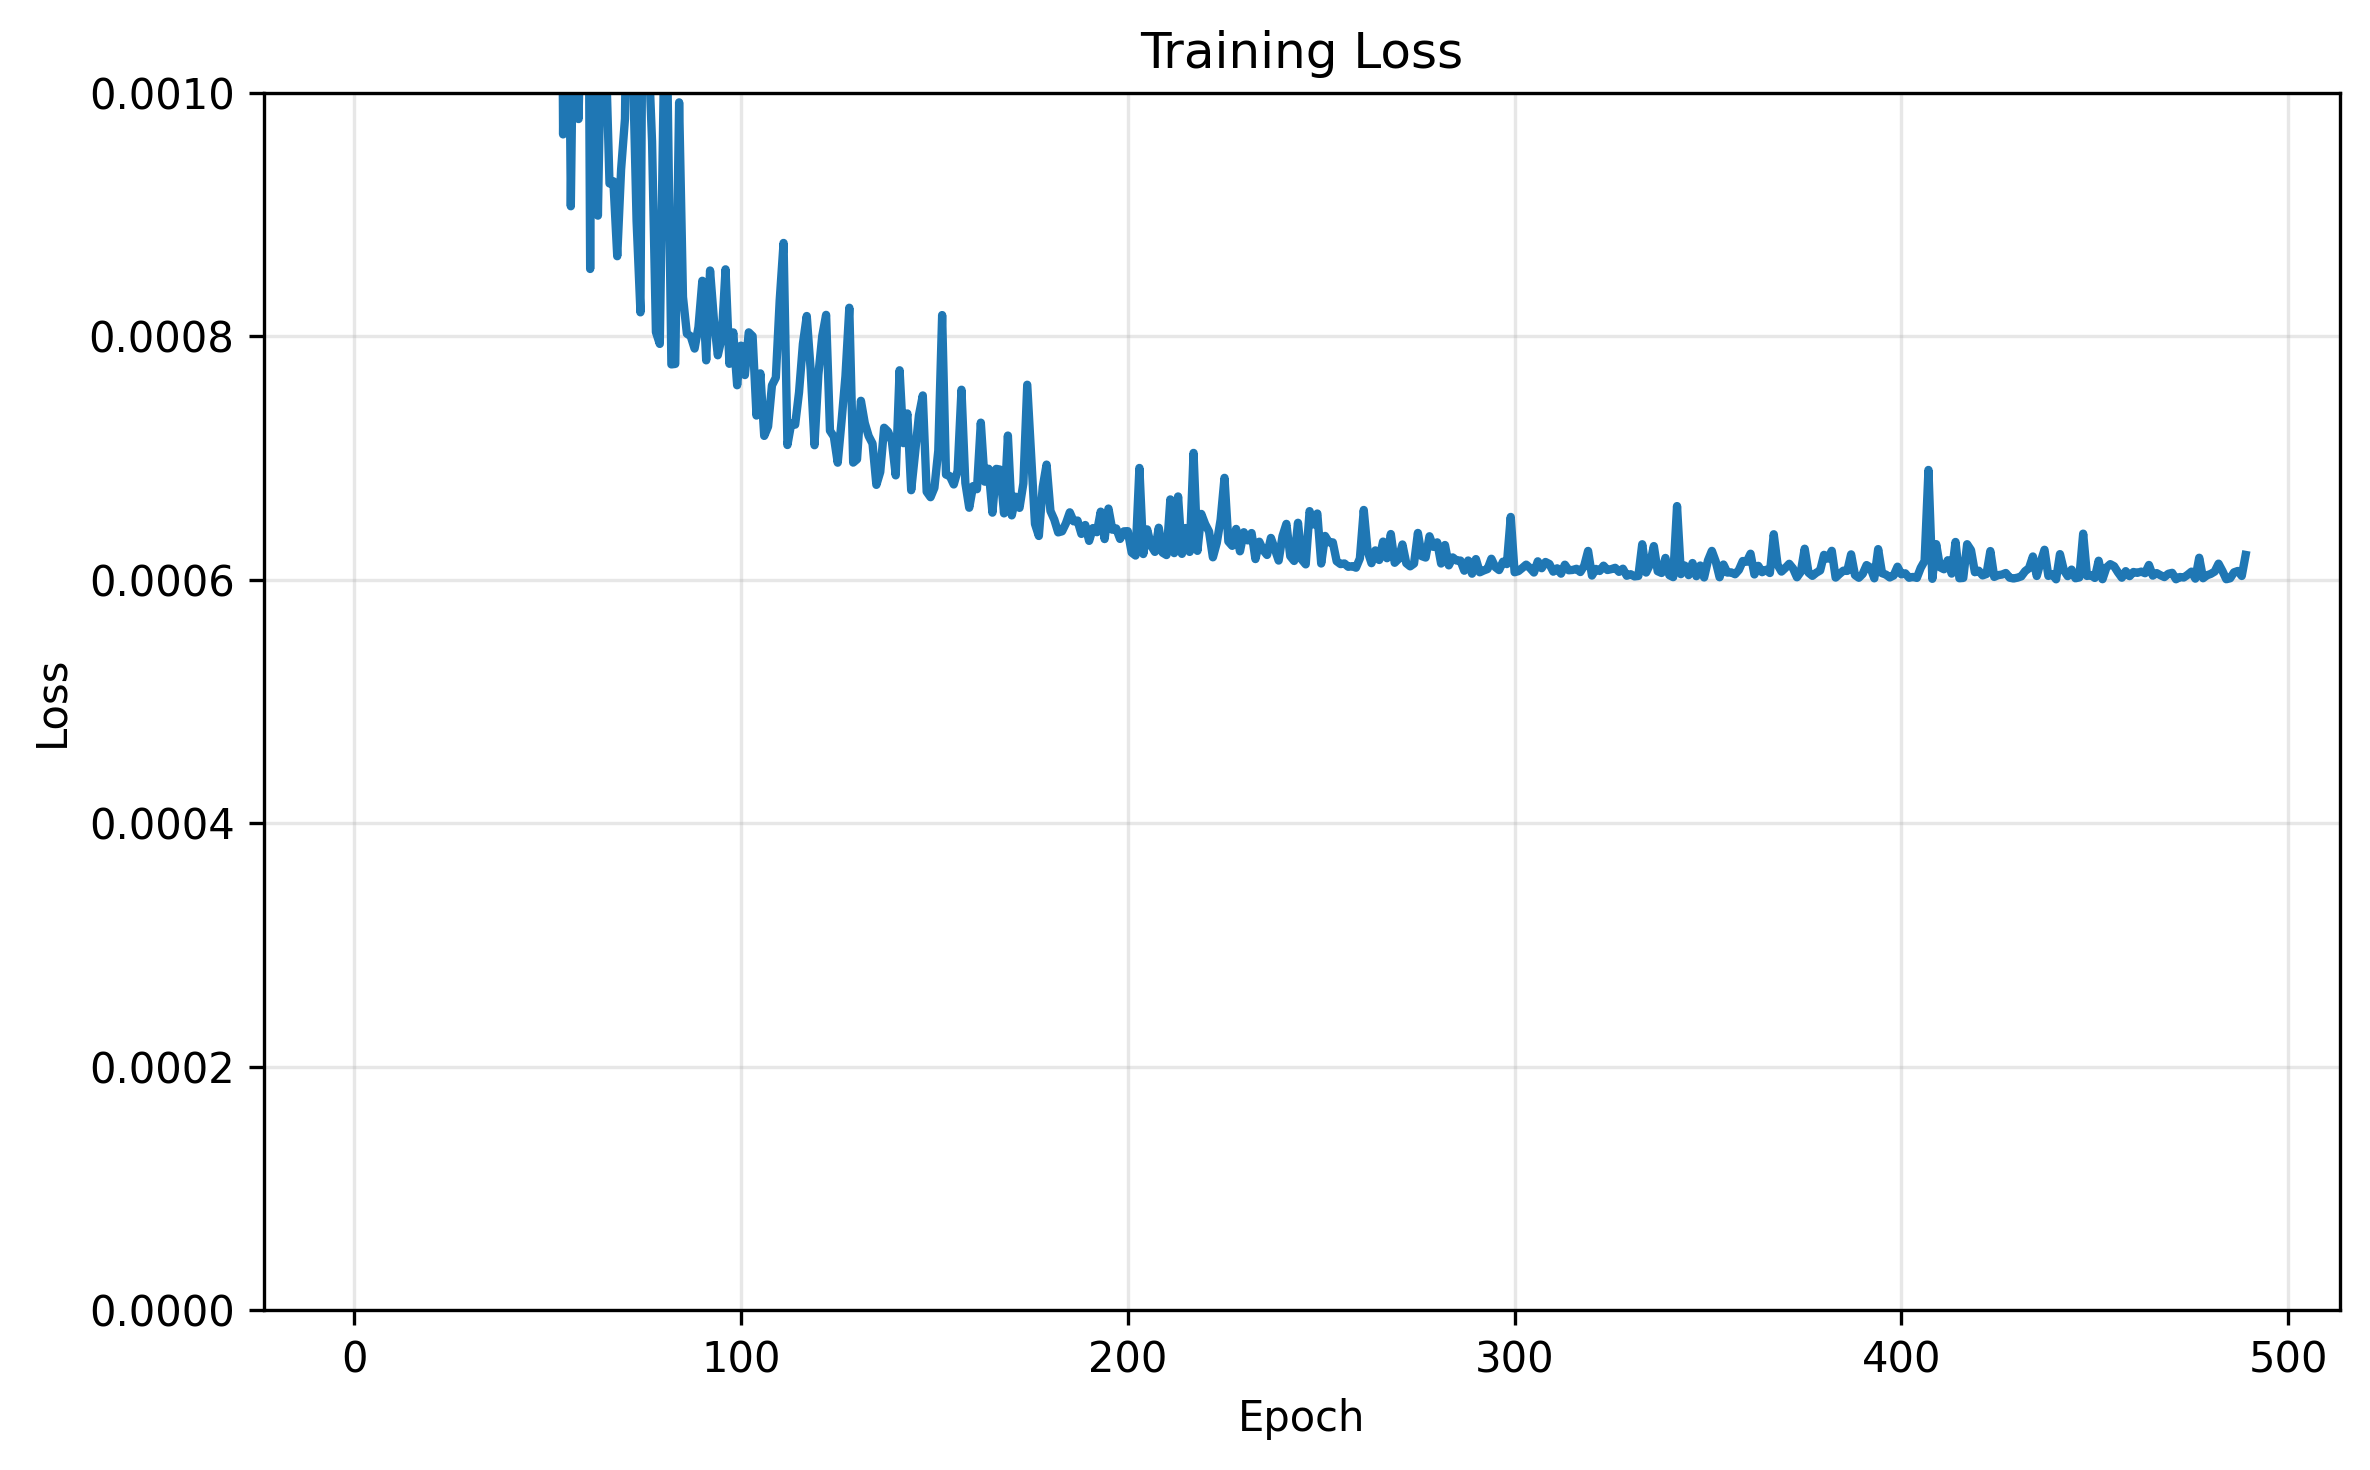

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

loss = np.asarray(history["loss"])

plt.figure(figsize=(8, 5), dpi=300)
plt.plot(np.arange(1, len(loss) + 1), loss, lw=2)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(alpha=0.3)
plt.ylim(0,0.001)
plt.tight_layout()
plt.show()

In [ ]:
samples = []
for i in range(10000):
    samples.append(nn_model()[0])
samples = torch.stack(samples).detach().cpu().numpy() # shape [N_samples, 5]

print(samples.shape)


(10000, 5)


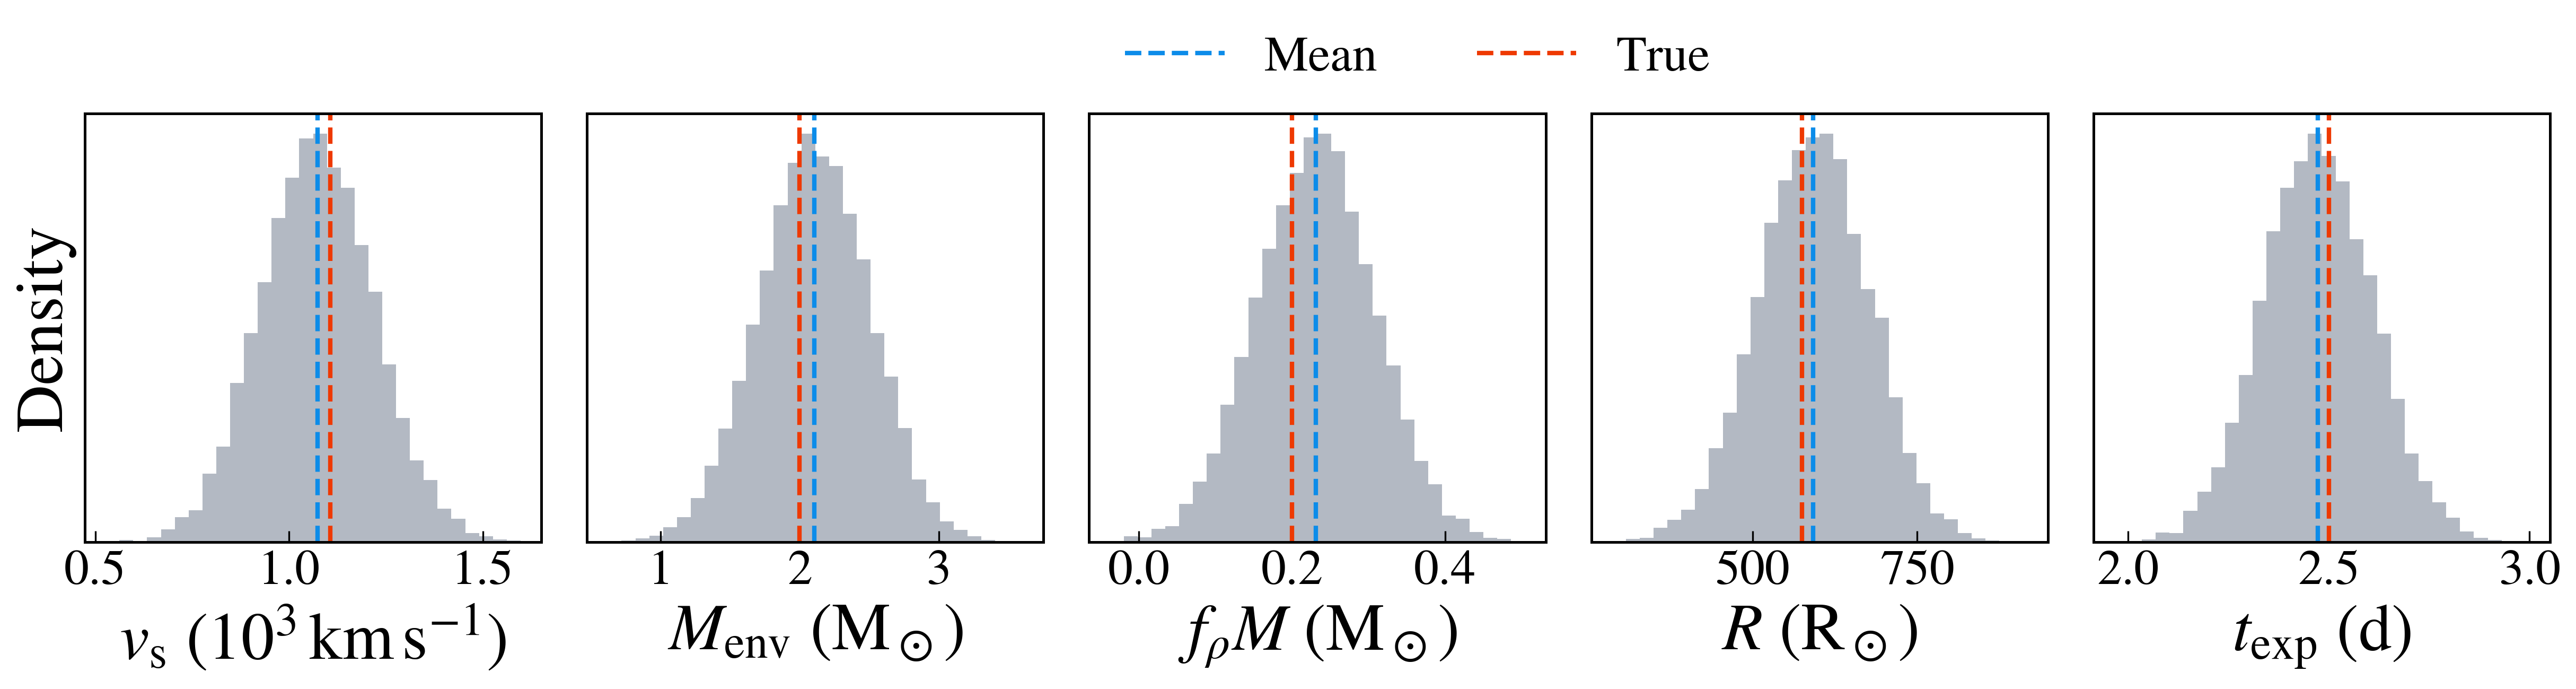

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import utils.paper_plot_style as pps

pps.set_thesis_style(25)

param_names = [
    r"$v_{\rm s}\ (10^3\,\mathrm{km\,s^{-1}})$",
    r"$M_{\rm env}\ (\mathrm{M}_\odot)$",
    r"$f_\rho M\ (\mathrm{M}_\odot)$",
    r"$R\ (\mathrm{R}_\odot)$",
    r"$t_{\rm exp}\ (\mathrm{d})$"
]
mean = samples.mean(0)
true = builder.model_parameters

# -------------------------
# Unit conversions
# -------------------------

# v_s: from 10^8.5 cm/s → 10^3 km/s
vs_unit = (10**8.5 * u.cm / u.s).to(1e3 * u.km / u.s).value

# M_env, f_rho M: already in Msun
msun_unit = 1.0

# R: from 1e13 cm → Rsun
R_unit = (1e13 * u.cm).to(u.Rsun).value

# t_exp: already in days
t_unit = 1.0

conv = np.array([vs_unit, msun_unit, msun_unit, R_unit, t_unit])

samples_conv = samples * conv
mean_conv = mean * conv
true_conv = true * conv

# -------------------------
# Plot
# -------------------------

fig, axes = plt.subplots(1, 5, figsize=(20, 3.5), dpi=300, sharey=False)
fig.subplots_adjust(wspace=.1)

blue = "#0C8CE9"
red = "#EE3902"
darkblue = "#04193B" 


for i, ax in enumerate(axes):
    ax.hist(samples_conv[:, i], bins=30, density=True, alpha=0.3, color=darkblue)

    ax.axvline(mean_conv[i], linestyle="--", lw=2, label="Mean", color=blue)
    ax.axvline(true_conv[i], linestyle="--", lw=2, label="True", color=red)

    ax.set_xlabel(param_names[i])

    if i == 0:
        ax.set_ylabel("Density")

# Single legend outside
handles, labels = axes[2].get_legend_handles_labels()
fig.legend(handles, labels, ncol=2, frameon=False, bbox_to_anchor=(.65, 1.1))
for ax in axes:
    ax.set_yticks([])
# plt.tight_layout(rect=[0, 0, 1, 0.9])
# plt.savefig("../outputs/thesis_parameters.png")



In [ ]:
1+1

2

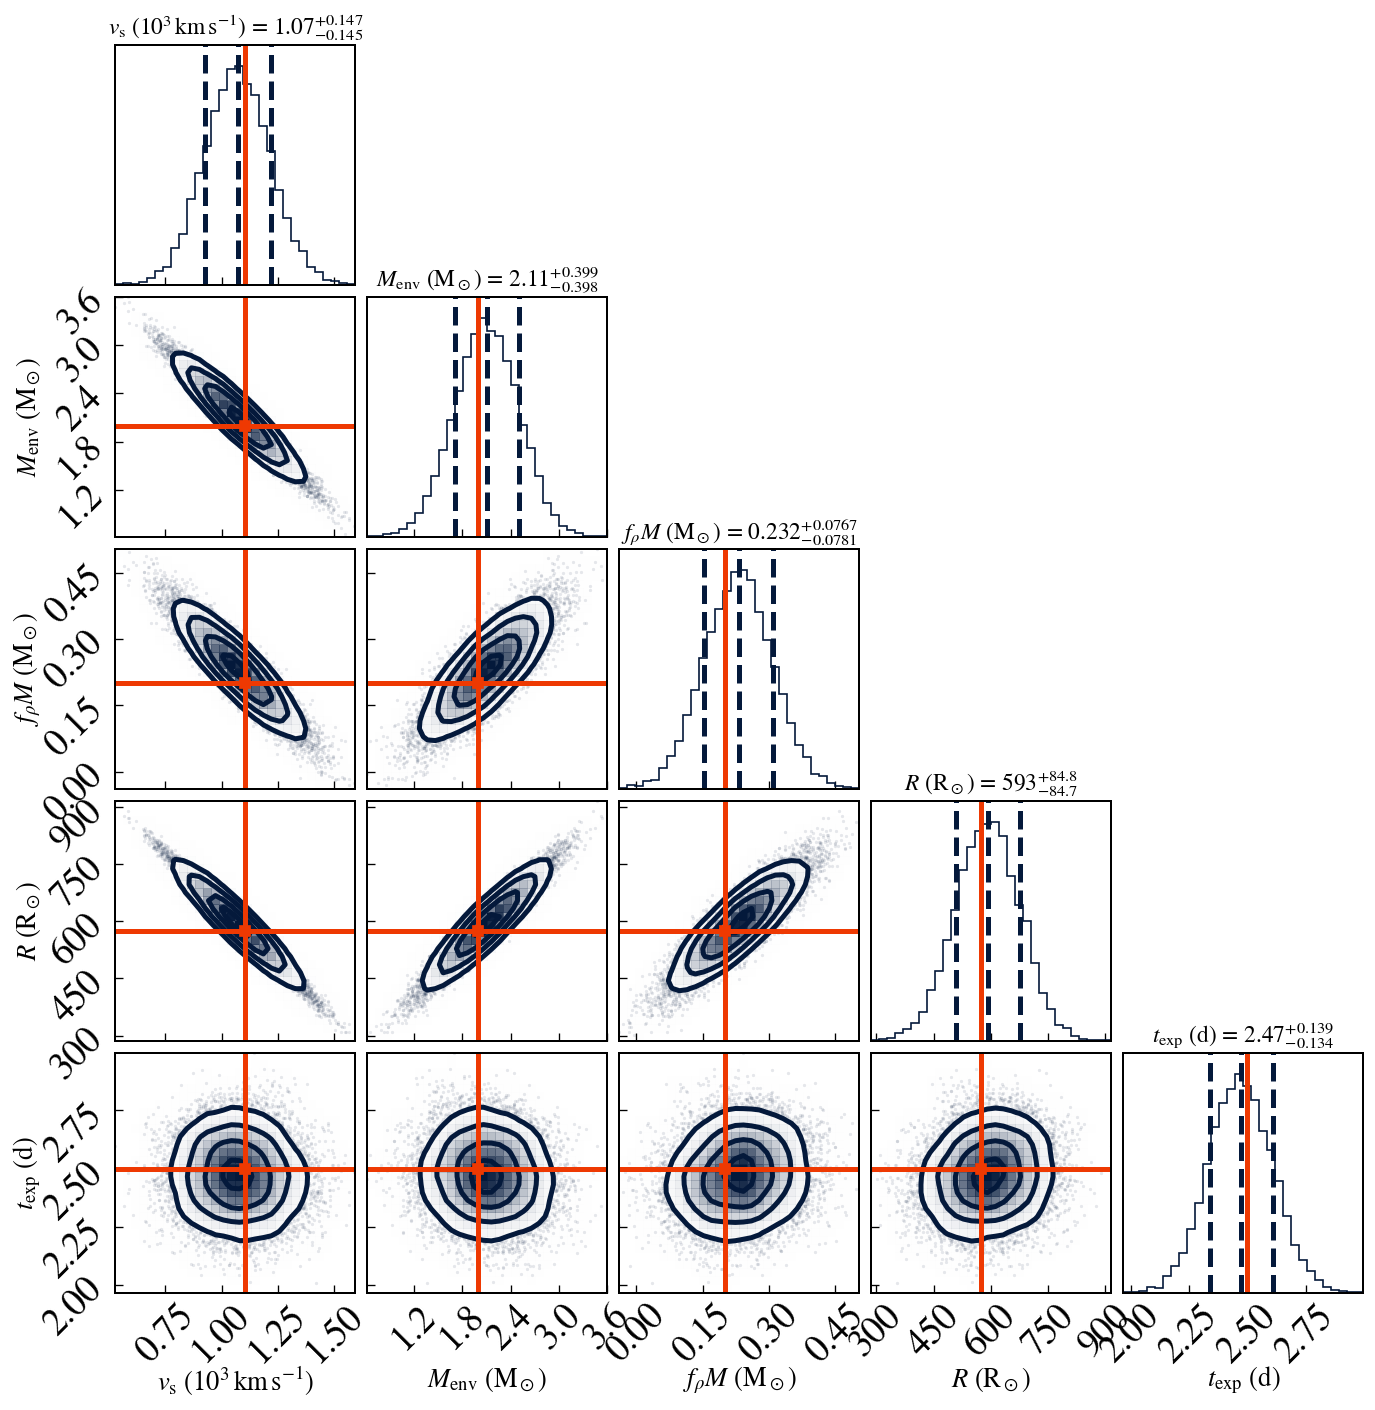

In [ ]:
import corner
import numpy as np
import matplotlib.pyplot as plt

# samples_conv has shape (N_samples, 5)

fig = corner.corner(
    samples_conv,
    labels=param_names,
    truths=true_conv,
    truth_color="#EE3902",
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_fmt=".3g",
    title_kwargs={"fontsize": 14},
    label_kwargs={"fontsize": 16},
    bins=30,
    smooth=1.0,
    color="#04193B",
    hist_kwargs={"density": True},
)

plt.show()

In [ ]:
import numpy as np

# -------------------------
# Conversions (same as before)
# -------------------------
import astropy.units as u

vs_unit = (10**8.5 * u.cm / u.s).to(1e3 * u.km / u.s).value
R_unit  = (1e13 * u.cm).to(u.Rsun).value

conv = np.array([vs_unit, 1.0, 1.0, R_unit, 1.0])

samples_conv = samples * conv

# Order: [v_s, M_env, f_rho M, R, t_exp]

# -------------------------
# Compute statistics
# -------------------------
mean = np.mean(samples_conv, axis=0)
p16  = np.percentile(samples_conv, 16, axis=0)
p84  = np.percentile(samples_conv, 84, axis=0)

err_minus = mean - p16
err_plus  = p84 - mean

# -------------------------
# Formatting helper
# -------------------------
def format_pm(val, err_m, err_p, sci=False):
    if sci:
        base = val / 1e3
        em = err_m / 1e3
        ep = err_p / 1e3
        return rf"{base:.2f}_{{-{em:.2f}}}^{{+{ep:.2f}}}\times10^3"
    else:
        return rf"{val:.2f}_{{-{err_m:.2f}}}^{{+{err_p:.2f}}}"

# -------------------------
# Build LaTeX string
# -------------------------
vs   = format_pm(mean[0]*1e3, err_minus[0]*1e3, err_plus[0]*1e3, sci=True)
Menv = format_pm(mean[1], err_minus[1], err_plus[1])
fpM  = format_pm(mean[2], err_minus[2], err_plus[2])
R    = format_pm(mean[3], err_minus[3], err_plus[3])
t0   = format_pm(mean[4], err_minus[4], err_plus[4])

latex = rf"""
\begin{{equation*}}
\begin{{gathered}}
R \approx {R}\,R_\odot,\quad
v_{{\rm s*}} \approx {vs}\,{{\rm km\,s^{{-1}}}},\quad
M_{{\rm env}} \approx {Menv}\,M_\odot,\\
f_\rho M \approx {fpM}\,M_\odot,\quad
t_0 \approx {t0}~\mathrm{{d}}.
\end{{gathered}}
\end{{equation*}}
"""

print(latex)


\begin{equation*}
\begin{gathered}
R \approx 592.43_{-83.96}^{+85.58}\,R_\odot,\quad
v_{\rm s*} \approx 1.07_{-0.15}^{+0.15}\times10^3\,{\rm km\,s^{-1}},\quad
M_{\rm env} \approx 2.11_{-0.40}^{+0.40}\,M_\odot,\\
f_\rho M \approx 0.23_{-0.08}^{+0.08}\,M_\odot,\quad
t_0 \approx 2.47_{-0.14}^{+0.14}~\mathrm{d}.
\end{gathered}
\end{equation*}



In [ ]:
import numpy as np
import astropy.units as u

# -------------------------
# Conversions
# -------------------------
vs_unit = (10**8.5 * u.cm / u.s).to(1e3 * u.km / u.s).value
R_unit  = (1e13 * u.cm).to(u.Rsun).value

conv = np.array([vs_unit, 1.0, 1.0, R_unit, 1.0])

# Convert samples
samples_conv = samples * conv

# True simulation parameters
model_parameters = np.array([0.35, 2.0, 0.2, 4.0, 2.5])
true_conv = model_parameters * conv

# -------------------------
# Compute statistics
# -------------------------
mean = np.mean(samples_conv, axis=0)
p16  = np.percentile(samples_conv, 16, axis=0)
p84  = np.percentile(samples_conv, 84, axis=0)

err_minus = mean - p16
err_plus  = p84 - mean

# Relative deviation (%)
rel = 100 * (mean - true_conv) / true_conv

# -------------------------
# Formatting helper
# -------------------------
def format_pm(val, err_m, err_p, sci=False):
    if sci:
        base = val / 1e3
        em = err_m / 1e3
        ep = err_p / 1e3
        return rf"{base:.2f}_{{-{em:.2f}}}^{{+{ep:.2f}}}\times10^3"
    else:
        return rf"{val:.2f}_{{-{err_m:.2f}}}^{{+{err_p:.2f}}}"

# -------------------------
# Build formatted values
# -------------------------
vs   = format_pm(mean[0] * 1e3, err_minus[0] * 1e3, err_plus[0] * 1e3, sci=True)
Menv = format_pm(mean[1], err_minus[1], err_plus[1])
fpM  = format_pm(mean[2], err_minus[2], err_plus[2])
R    = format_pm(mean[3], err_minus[3], err_plus[3])
t0   = format_pm(mean[4], err_minus[4], err_plus[4])

# -------------------------
# LaTeX output
# -------------------------
latex = rf"""
\begin{{equation*}}
\begin{{aligned}}
R &\approx {R}\,R_\odot
\: (\Delta={rel[3]:+.1f}\%) \\
v_{{\rm s*}} &\approx {vs}\,\mathrm{{km\,s^{{-1}}}}
\: (\Delta={rel[0]:+.1f}\%) \\
M_{{\rm env}} &\approx {Menv}\,M_\odot
\: (\Delta={rel[1]:+.1f}\%) \\
f_\rho M &\approx {fpM}\,M_\odot
\: (\Delta={rel[2]:+.1f}\%) \\
t_0 &\approx {t0}\,\mathrm{{d}}
\: (\Delta={rel[4]:+.1f}\%)
\end{{aligned}}
\end{{equation*}}
"""

print(latex)


\begin{equation*}
\begin{aligned}
R &\approx 592.43_{-83.96}^{+85.58}\,R_\odot
\: (\Delta=+3.0\%) \\
v_{\rm s*} &\approx 1.07_{-0.15}^{+0.15}\times10^3\,\mathrm{km\,s^{-1}}
\: (\Delta=-3.0\%) \\
M_{\rm env} &\approx 2.11_{-0.40}^{+0.40}\,M_\odot
\: (\Delta=+5.3\%) \\
f_\rho M &\approx 0.23_{-0.08}^{+0.08}\,M_\odot
\: (\Delta=+15.7\%) \\
t_0 &\approx 2.47_{-0.14}^{+0.14}\,\mathrm{d}
\: (\Delta=-1.1\%)
\end{aligned}
\end{equation*}



/tmp/ipykernel_1289177/1577293248.py:37: RuntimeWarning: divide by zero encountered in log10
  ax.plot(t_grid, np.log10(mod_vals.squeeze()) + offsets[filt], color=filtstyle["color"], alpha=0.05, zorder=0)


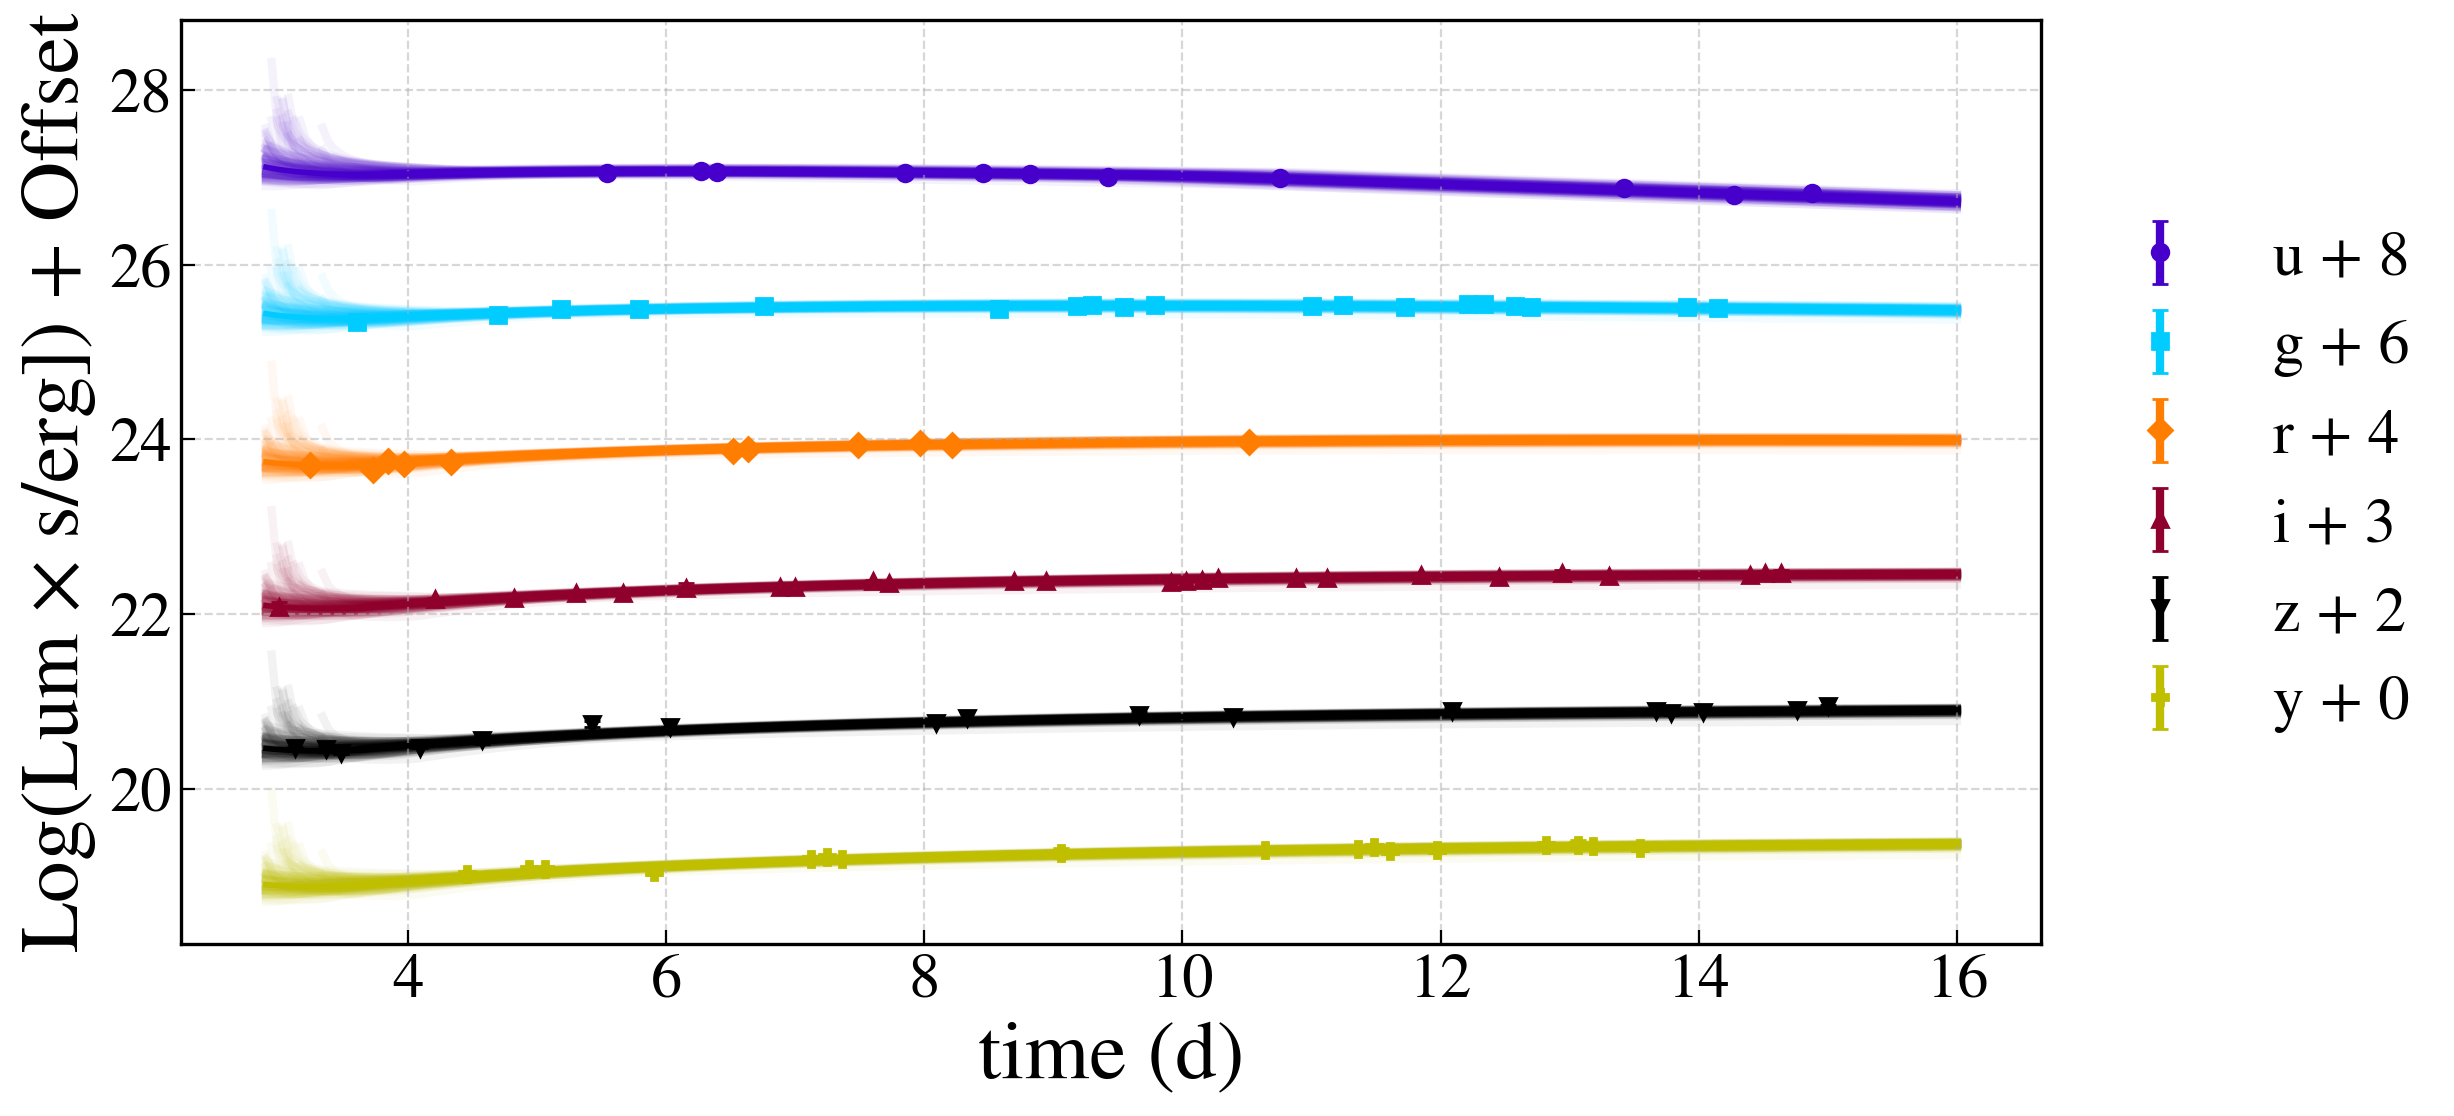

In [ ]:
model = models.ModifiedShockCooling4(lc)
ycol="loglum"
offset=1.5
kappa=1

filters = np.unique(lc['filter'])
markers = ['o', 's', 'D', '^', 'v', 'P', '*', 'X']
scale = 1e19 if ycol == "lum" else 1
offsets = {filt: i * offset * scale for i, filt in enumerate(filters[::-1])}

fig, ax = plt.subplots(figsize=(12, 6), dpi=200)

# Plot observed data
for i, filt in enumerate(filters):
    mask = lc['filter'] == filt
    mjd = lc['MJD'][mask]
    y = lc[ycol][mask] + offsets[filt]
    yerr = lc["d" + ycol][mask]
    marker = markers[i % len(markers)]
    style = filt.plotstyle if hasattr(filt, 'plotstyle') else {}

    ax.errorbar(mjd, y, yerr=yerr, fmt=marker,
                label=f"{filt} + {offsets[filt]:.1g}",
                capsize=3, **style)

# Time grid for model evaluation
t_grid = np.linspace(lc['MJD'].min() - .1, lc['MJD'].max() + 1, 300)

# Plot sampled models
for p in samples[np.random.choice(len(samples), size=min(100, len(samples)), replace=False)]:
    v_s, M_env, f_rho_M, R, t_exp = p
    for filt in filters:
        mod_vals = model.evaluate(t_grid, [filt], v_s, M_env, f_rho_M, R, t_exp, kappa)
        filtstyle = filt.plotstyle.copy()
        # print(filtstyle)
        # aaaaa
        ax.plot(t_grid, np.log10(mod_vals.squeeze()) + offsets[filt], color=filtstyle["color"], alpha=0.05, zorder=0)

# Plot median model
v_s, M_env, f_rho_M, R, t_exp = np.median(samples, axis=0)
for filt in filters:
    mod_vals = model.evaluate(t_grid, [filt], v_s, M_env, f_rho_M, R, t_exp, kappa)
    filtstyle = filt.plotstyle.copy()

    ax.plot(t_grid, np.log10(mod_vals.squeeze()) + offsets[filt], lw=2, label=f"_Median model - {filt}", c=filtstyle["color"])

# Final touches
ax.set_xlabel("time (d)")
ax.set_ylabel(f"Log(Lum $\\times$ s/erg]) + Offset")
if ycol == "lum":
    ax.set_yscale("log")
ax.grid(True, linestyle='--', alpha=0.5)
# ax.set_title("Light Curve with Model Fits (per filter)")
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
# plt.tight_layout()
# plt.savefig("../outputs/thesis_lc.png")


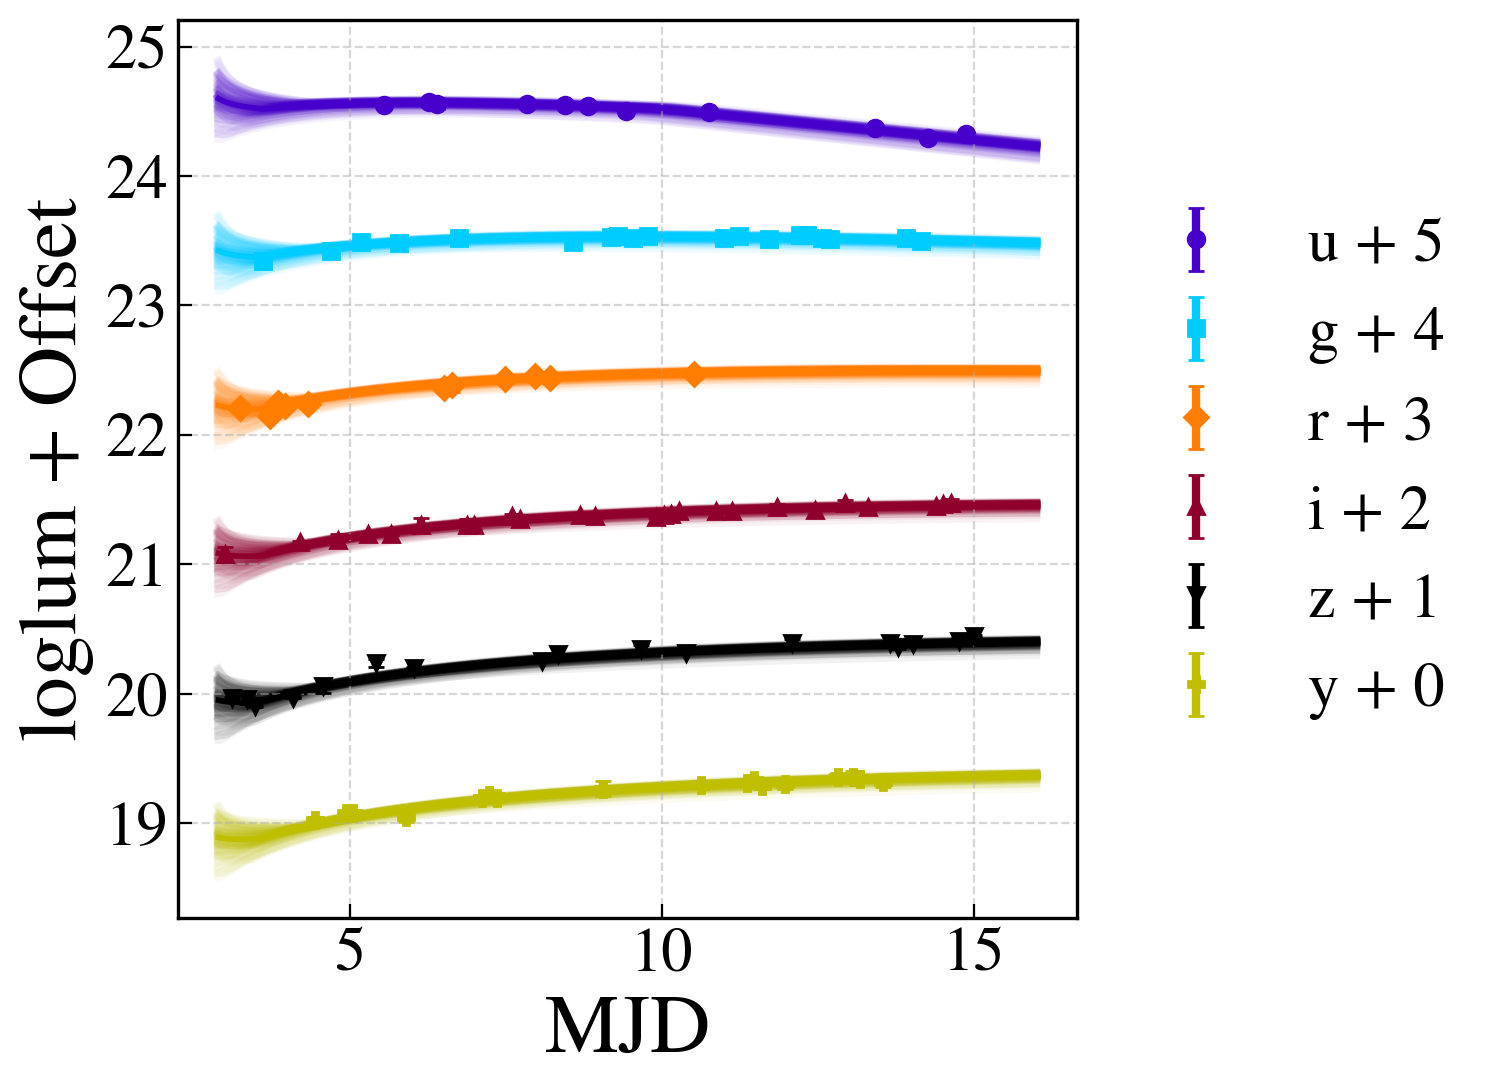

In [ ]:
model = models.ModifiedShockCooling4(lc)
an.lc_modeling_plot(lc=lc, samples=samples, model=model, ycol="loglum", offset=1)

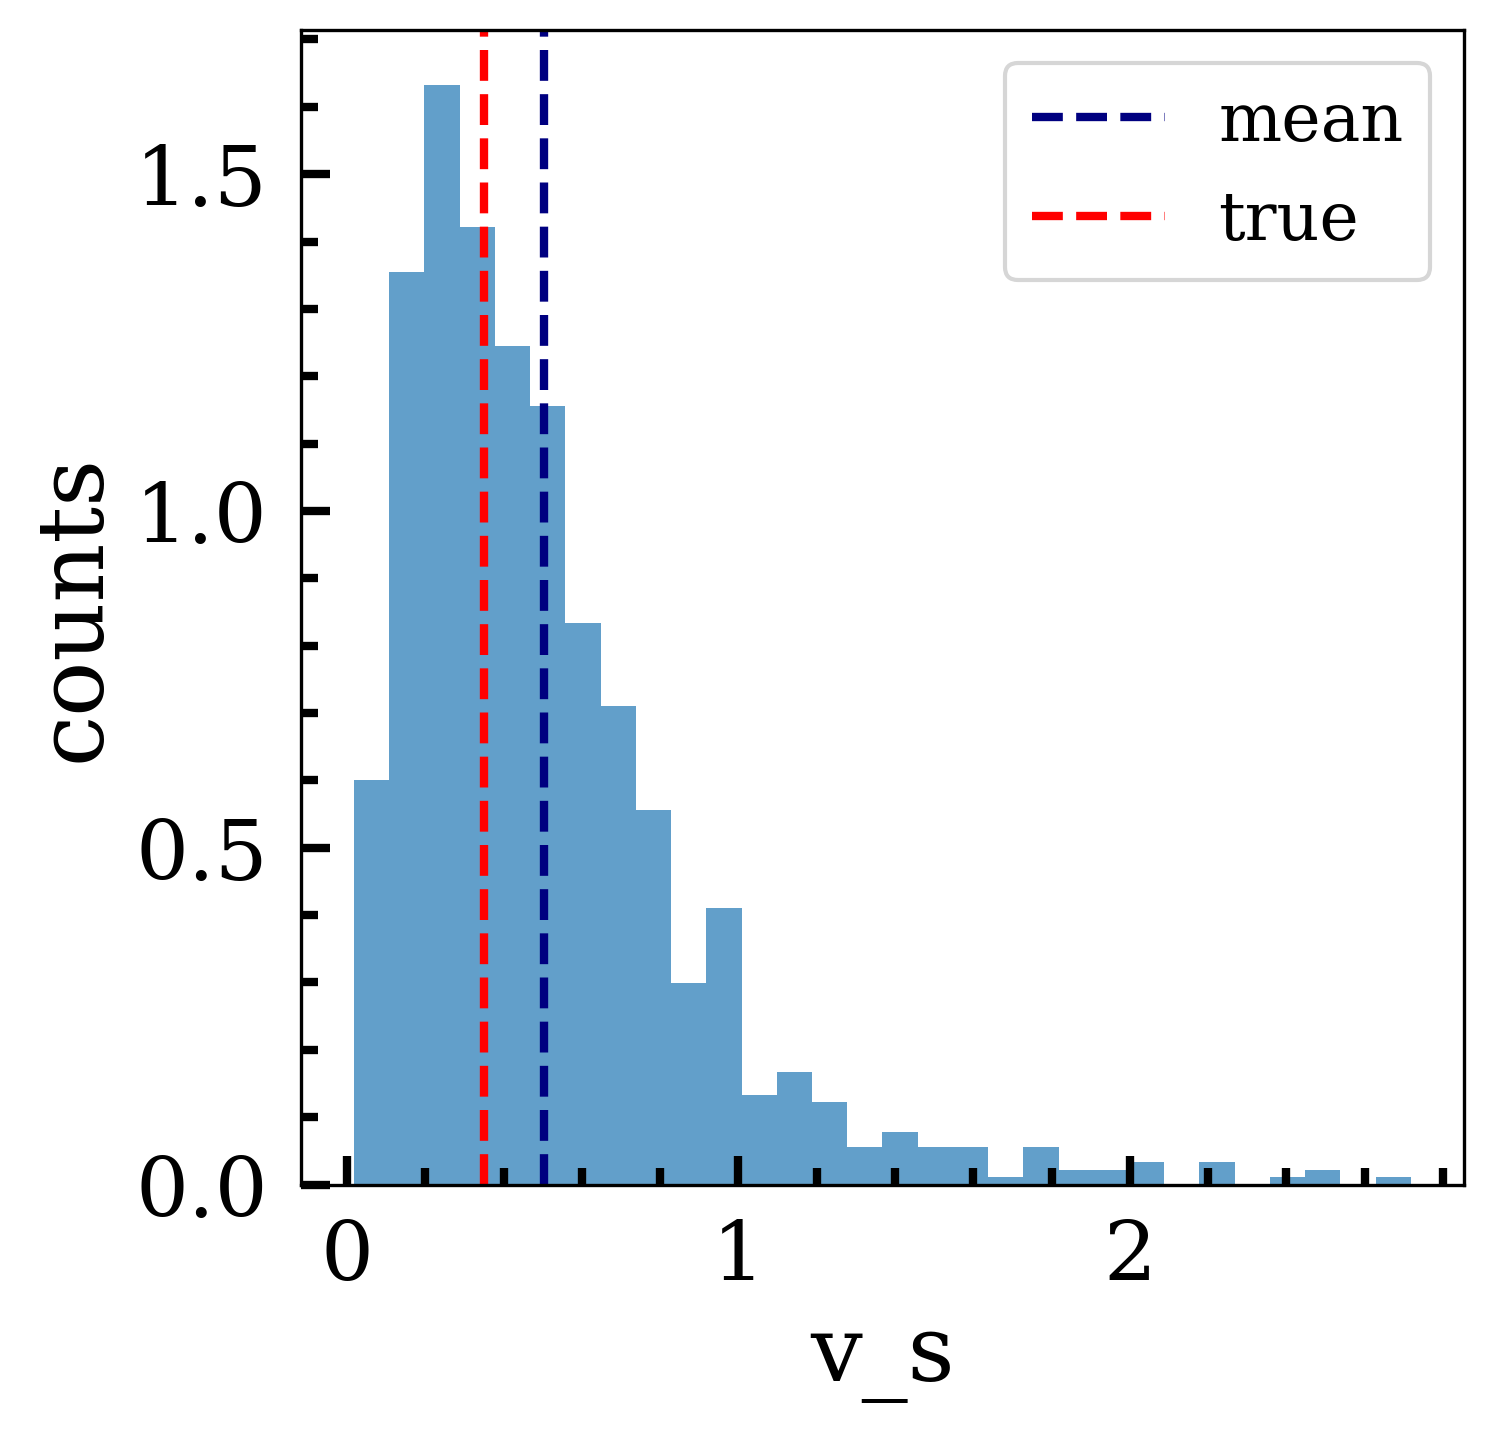

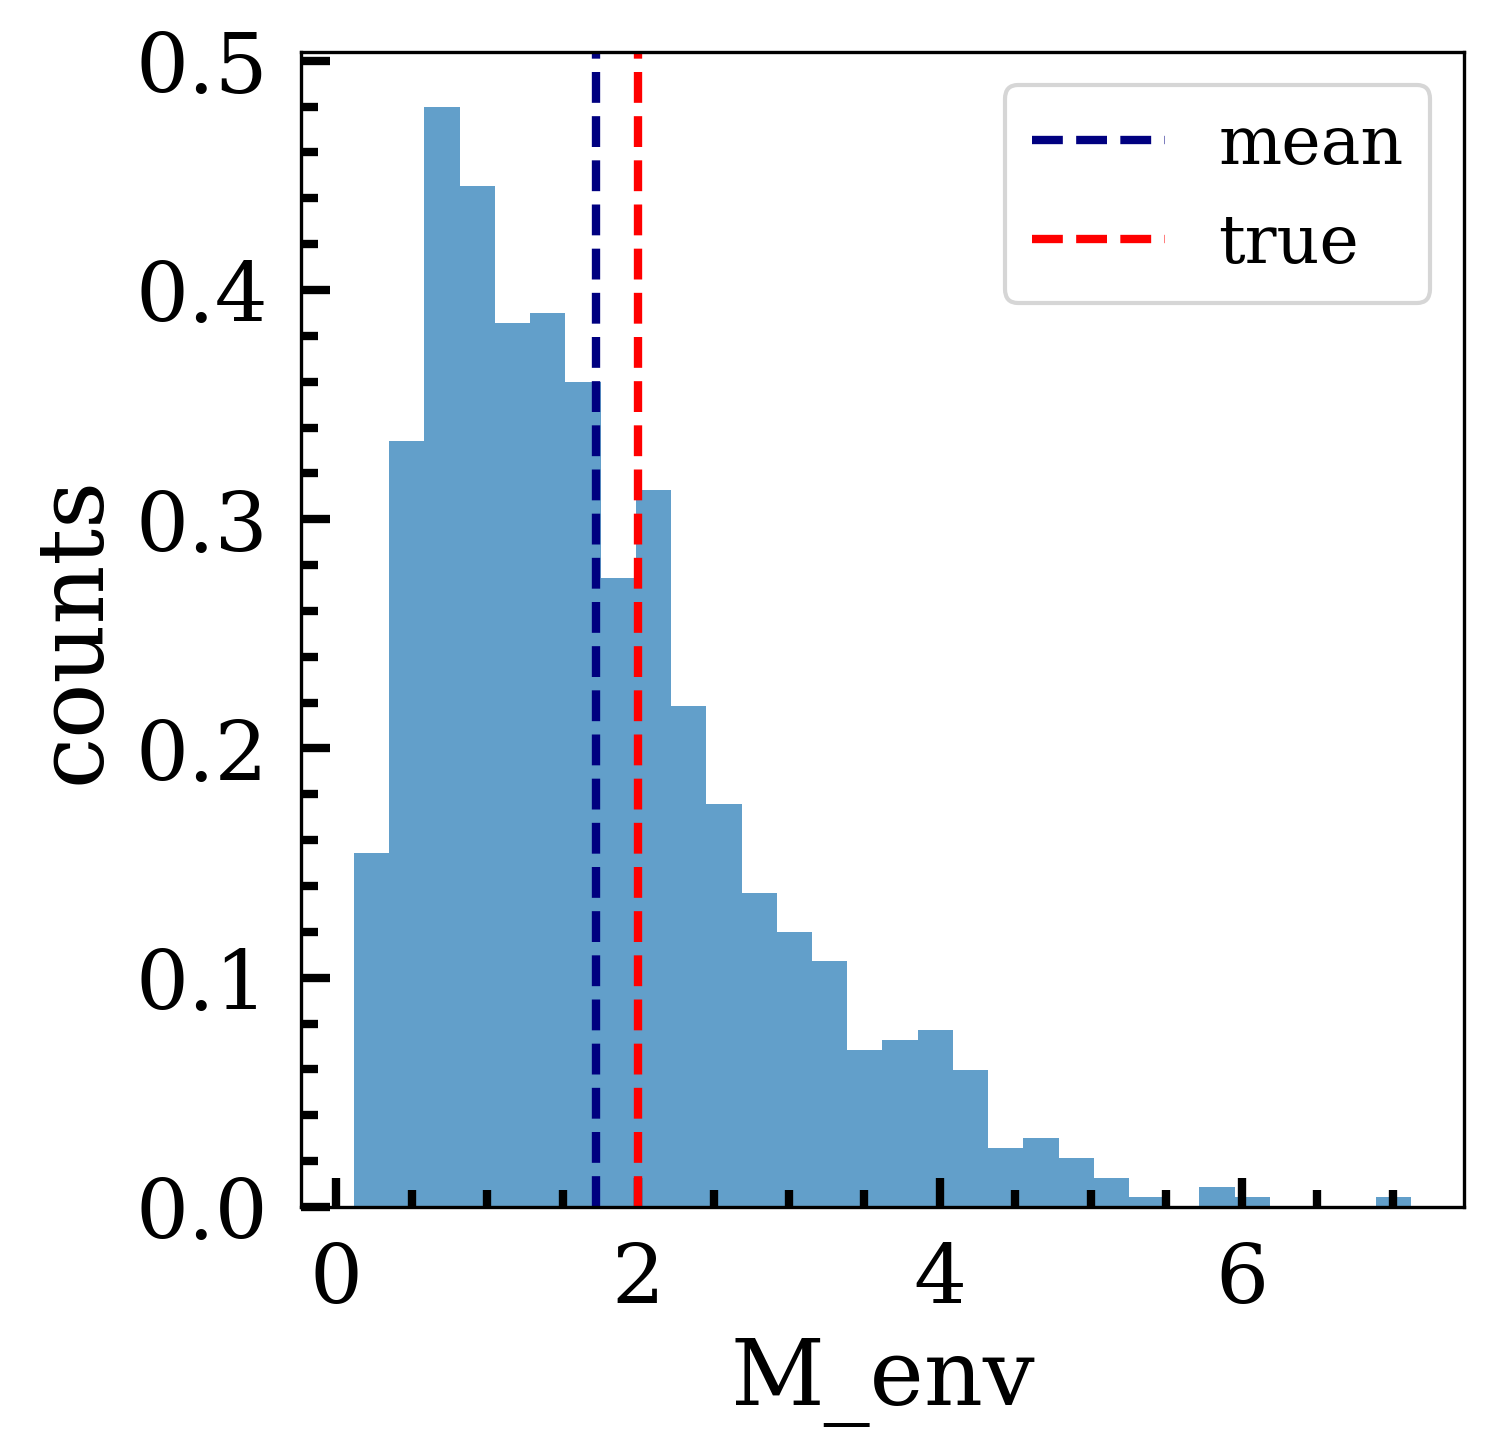

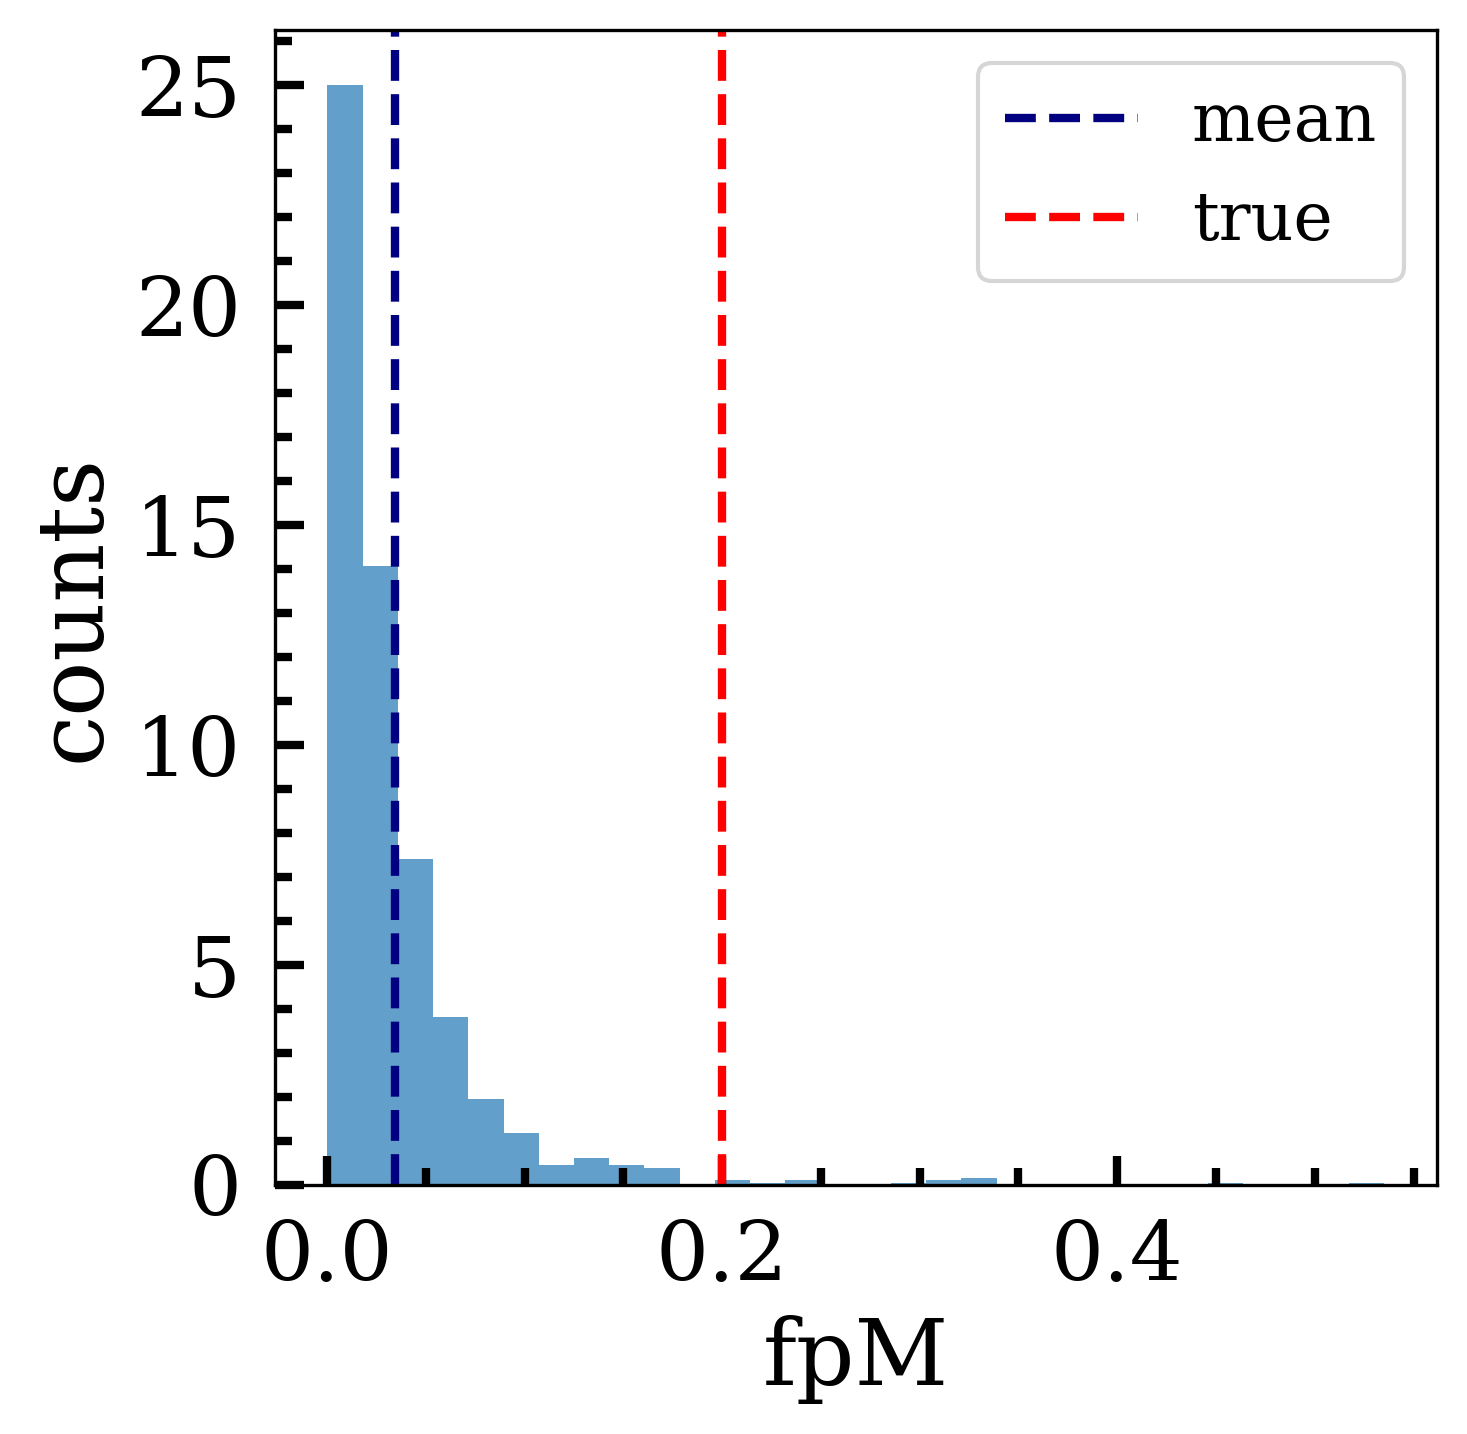

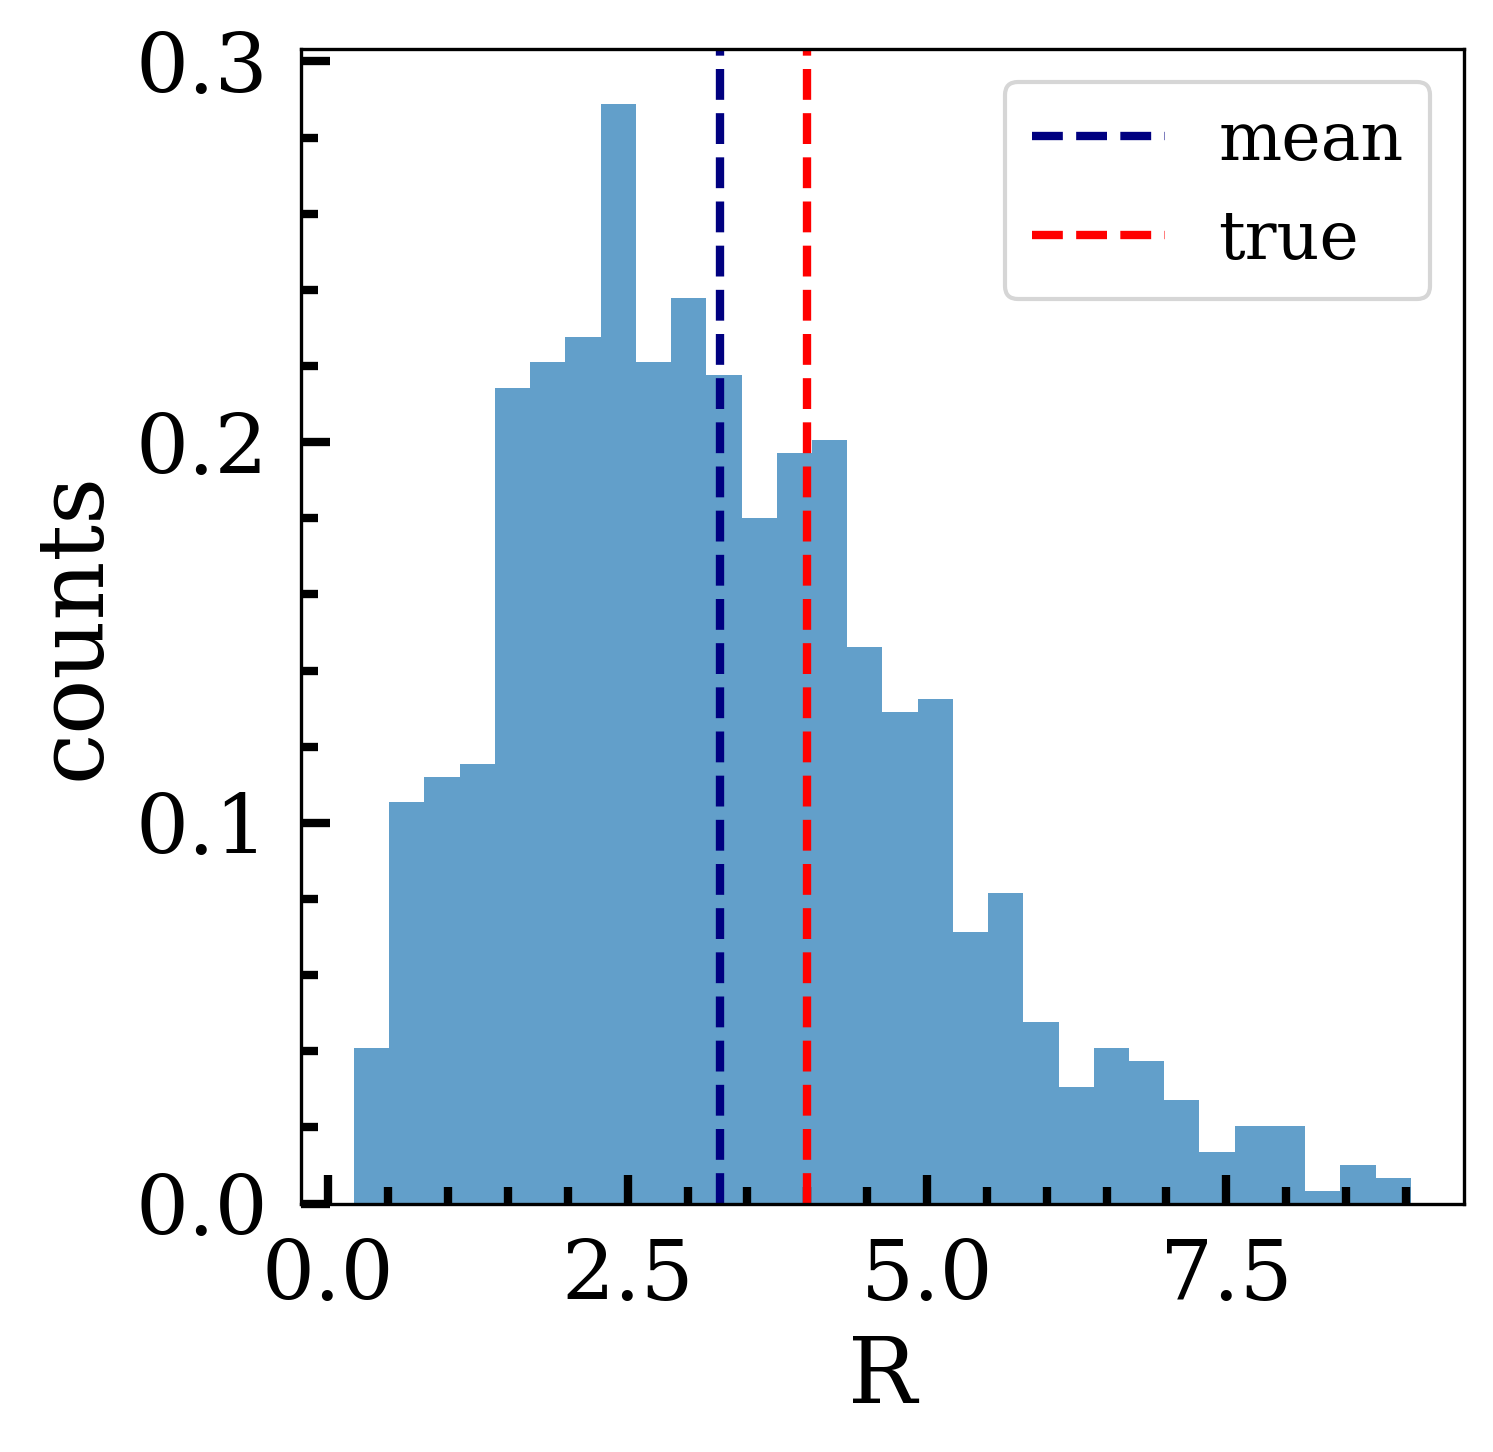

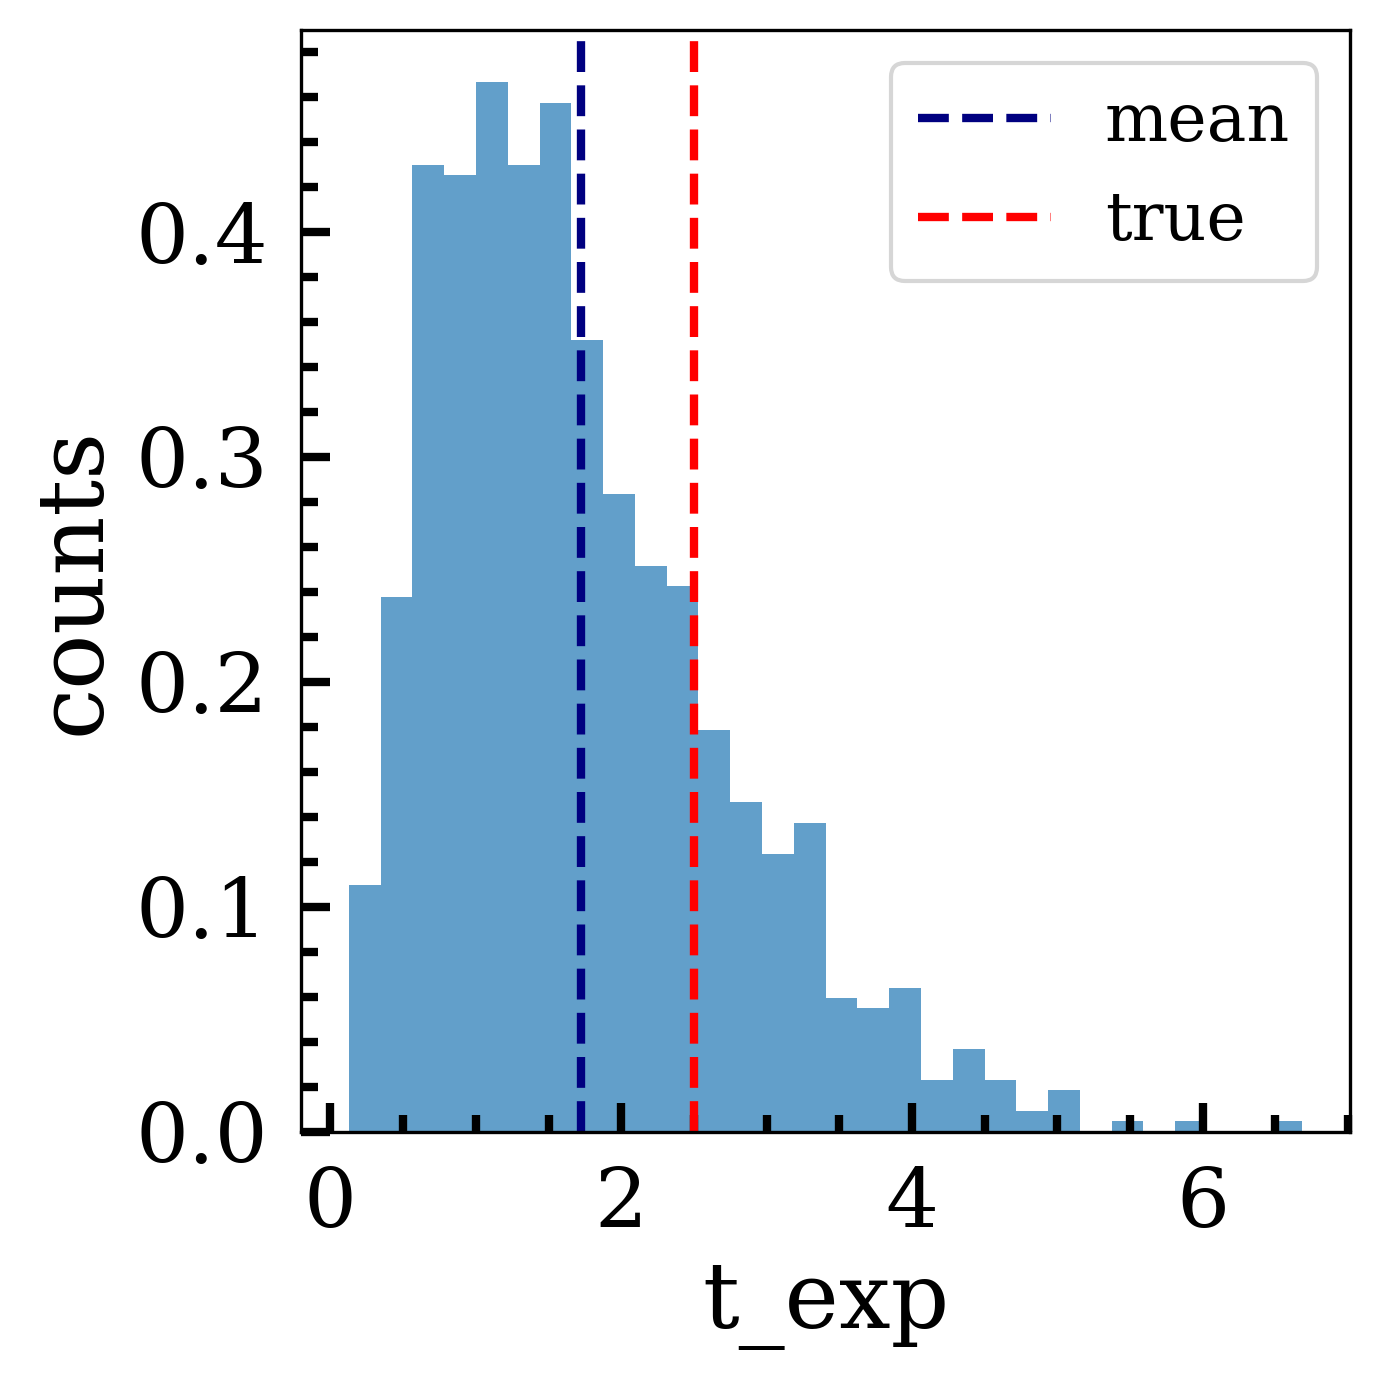

In [ ]:
import utils.paper_plot_style as pps
pps.set_plot_style()

param_names = ["v_s", "M_env","fpM",  "R", "t_exp"]
mean = samples.mean(0)
std = samples.std(0)
true = builder.model_parameters
# fig, axes = plt.subplots(1, 5, figsize=(30, 5), dpi=300)
for i, name in enumerate(param_names):
    fig, axes = plt.subplots(1, 1, figsize=(5, 5), dpi=300)
    axes.hist(samples[:, i], bins=30, density=True, color="tab:blue", alpha=0.7)
    axes.axvline(mean[i], color="navy", linestyle="--", label="mean", lw=2)
    axes.axvline(true[i], color="red", linestyle="--", label="true", lw=2)


    axes.set_xlabel(name)
    axes.set_ylabel("counts")
    axes.legend()

plt.tight_layout()
plt.show()

In [ ]:
(np.array(samples.mean(0) - model_parameters) )/np.array(model_parameters)

array([ 0.4284348 , -0.08131307, -0.8256569 , -0.16129665, -0.29903132])

In [ ]:
samples.mean(0)

array([0.49995218, 1.83737386, 0.03486862, 3.35481339, 1.75242169])

/tf/ProjectGabriel/pilca/utils/analysis.py:68: RuntimeWarning: divide by zero encountered in log10
  ax.plot(t_grid, np.log10(mod_vals.squeeze()) + offsets[filt], color=filtstyle["color"], alpha=0.05, zorder=0)


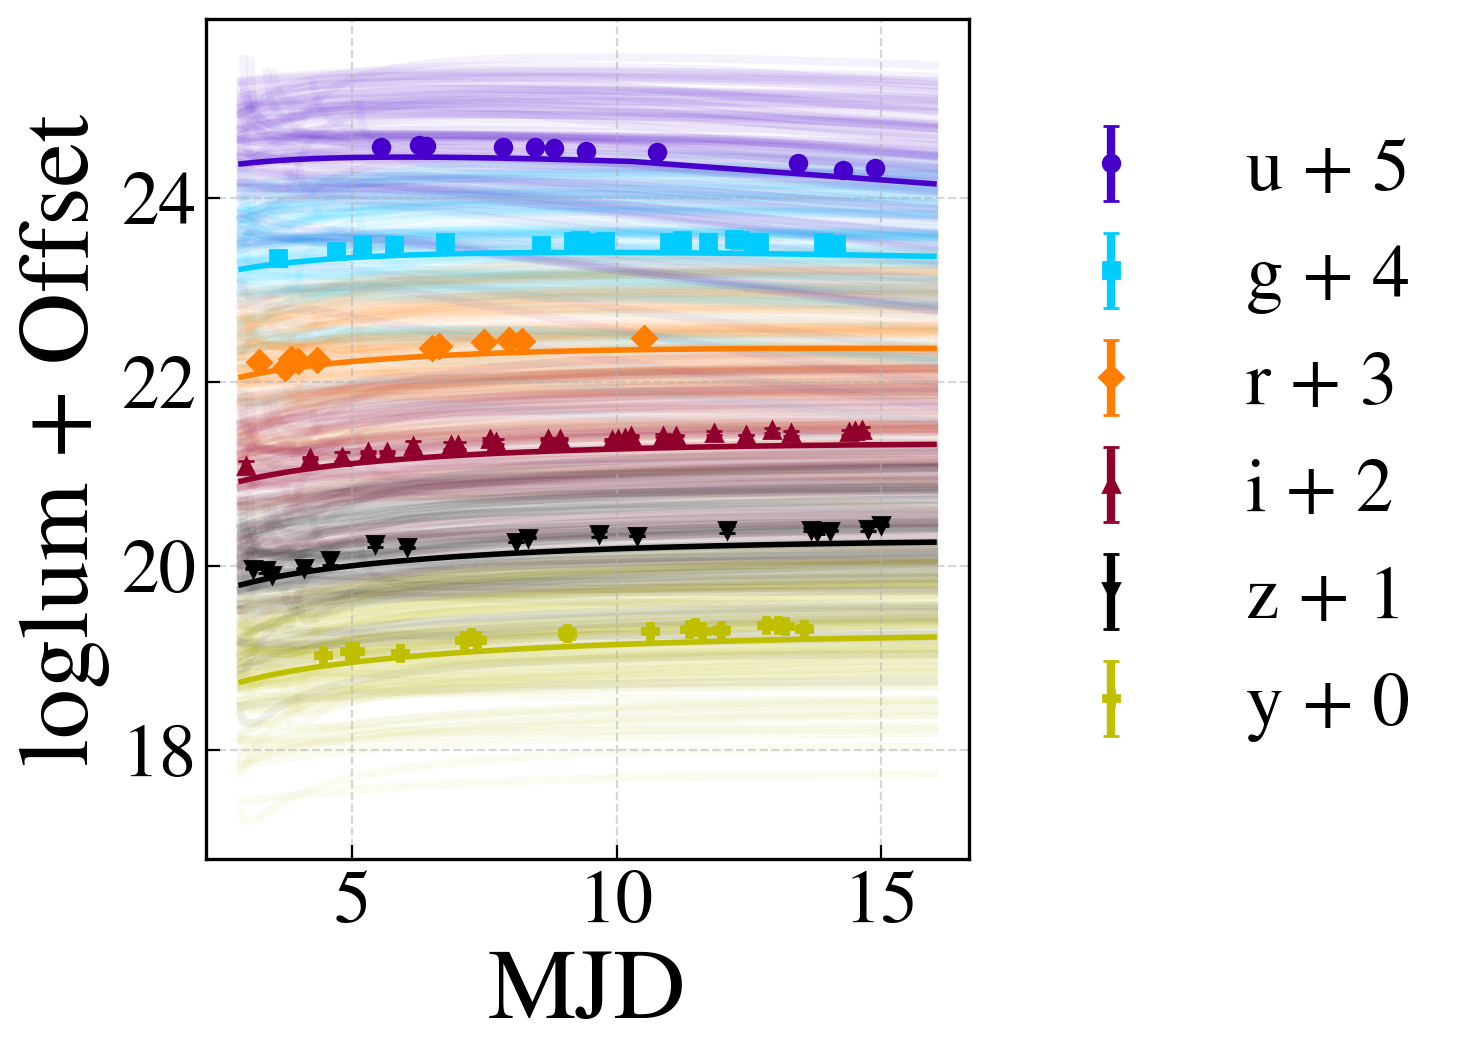

In [ ]:
model = models.ModifiedShockCooling4(lc)
an.lc_modeling_plot(lc=lc, samples=samples, model=model, ycol="loglum", offset=1)

(0.0, 0.1)

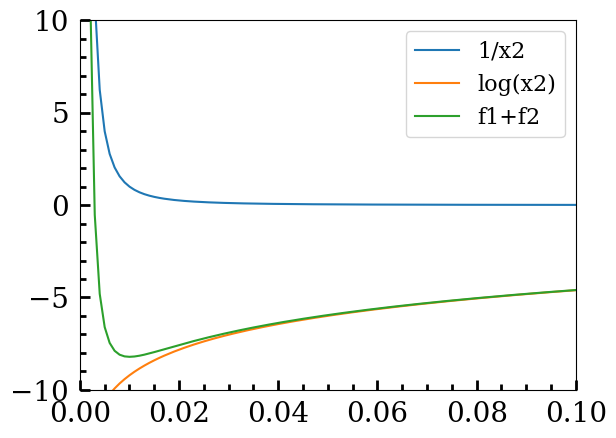

In [ ]:
x  = np.linspace(1e-8, 1, 1000)
f1 = lambda x: 1e-4/x**2
f2 = lambda x: np.log(x**2)

plt.plot(x, f1(x), label="1/x2")
plt.plot(x, f2(x), label="log(x2)")
plt.plot(x, f1(x)+f2(x), label="f1+f2")
plt.legend()
plt.ylim(-10,10)
plt.xlim(-0,1e-1)
